# SST Pipeline — Sea Surface Temperature Feature Engineering
## Tony Lin | ISEF Kelp Forest Collapse Prediction

---

### What this notebook does
Documents every step of the SST data pipeline:

| Step | What happens | Output |
|------|-------------|--------|
| 1 | Extract NOAA OISST monthly SST via OPeNDAP | Raw SST time series per region |
| 2 | Compute anomalies vs 1991–2020 climatology | SST anomaly (°C above/below baseline) |
| 3 | Aggregate to quarterly features | sstanom_q_mean, sstanom_q_max, sstanom_pos_sum, sstanom_exceed_months |
| 4 | Lag sweep (0–8 quarters) | AUC vs lag curve — find optimal predictive lag |
| 5 | Statistical significance tables | Block bootstrap CI, point-biserial correlation, Mann-Whitney U |
| 6 | Lagged overlay visualization | SST anomaly vs suppression label aligned at best lag |

**Key finding:** SST anomaly max (`sstanom_q_max`) predicts suppression best at **lag = 3–4 quarters** (9–12 months). This is your `heat_lag4` feature used in the ML model.

In [1]:
# ============================================================
# CELL 1: IMPORTS & CONFIG
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import pointbiserialr, mannwhitneyu, ttest_ind
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

BASE    = Path('../../1_DATA/processed')
FIG_DIR = Path('../../5_FIGURES/sst_pipeline')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.4,
    'figure.dpi':        150,
})

REGION_COLORS = {'norcal':'#1f77b4','midcal':'#d6604d','socal':'#2ca02c','bigsur':'#9467bd'}
REGION_NAMES  = {'norcal':'Northern CA','midcal':'Central CA','socal':'Southern CA','bigsur':'Big Sur'}
REGIONS       = ['norcal','midcal','socal','bigsur']

# SST feature names and what they measure
SST_FEATURES = {
    'sstanom_q_mean':          'Mean SST anomaly (°C) — average heat stress across quarter',
    'sstanom_q_max':           'Max SST anomaly (°C) — peak heat stress in quarter',
    'sstanom_pos_sum':         'Positive anomaly sum — total heat accumulation (°C·months)',
    'sstanom_exceed_months':   'Months exceeding +1°C anomaly — heat event duration',
}

print('✓ Config ready. FIG_DIR:', FIG_DIR.resolve())
print()
print('SST features that will be evaluated:')
for f, desc in SST_FEATURES.items():
    print(f'  {f:30s} — {desc}')

✓ Config ready. FIG_DIR: /Users/tonylin/Documents/kelp_project/5_FIGURES/sst_pipeline

SST features that will be evaluated:
  sstanom_q_mean                 — Mean SST anomaly (°C) — average heat stress across quarter
  sstanom_q_max                  — Max SST anomaly (°C) — peak heat stress in quarter
  sstanom_pos_sum                — Positive anomaly sum — total heat accumulation (°C·months)
  sstanom_exceed_months          — Months exceeding +1°C anomaly — heat event duration


---
## Step 1 & 2 — SST Extraction and Anomaly Computation

### Data source
**NOAA OISST v2 High Resolution** (0.25° × 0.25° grid, monthly) accessed via OPeNDAP:
`https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc`

For each region, SST is spatially averaged within the bounding box, then anomalies are computed:

```
sst_anom(t) = sst(t) − climatology(month_of_t)
```

where `climatology` = mean SST for that calendar month over **1991–2020** (WMO standard baseline).

### Why 1991–2020 baseline, not 1984–2013?
The kelp suppression baseline uses 1984–2013 to avoid contamination from the 2014 Blob. For SST anomalies, the **WMO standard 1991–2020 climatology** is used instead — this is the published standard for SST anomaly products and ensures your anomaly values are directly comparable to published climate indices. The two baselines serve different purposes and that is defensible.

In [2]:
# ============================================================
# CELL 2: LOAD LABELED DATA (SST features already computed)
# ============================================================
def load_region(region):
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / region / f'{region}_kelp_sst_labeled.csv',
        BASE / f'{region}_kelp_sst_labeled.csv',
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')
            df['region'] = region
            return df
    raise FileNotFoundError(f'No file found for {region}')

print('Loading regions...')
region_dfs = {}
for r in REGIONS:
    try:
        df = load_region(r)
        region_dfs[r] = df
        sst_cols = [c for c in df.columns if 'sst' in c.lower()]
        print(f'  ✓ {r}: {len(df)} quarters | SST columns: {sst_cols}')
    except FileNotFoundError as e:
        print(f'  ✗ {e}')

print(f'\nLoaded {len(region_dfs)} regions.')

Loading regions...
  ✓ norcal: 152 quarters | SST columns: ['sstanom_q_mean', 'sstanom_q_max', 'sstanom_q_mean_lag1']
  ✓ midcal: 157 quarters | SST columns: ['sstanom_q_mean', 'sstanom_q_max', 'sstanom_q_mean_lag1']
  ✓ socal: 167 quarters | SST columns: ['sst_q_mean', 'sstanom_q_mean', 'sstanom_q_max', 'sstanom_q_mean_lag1']
  ✓ bigsur: 158 quarters | SST columns: ['sst_q_mean', 'sstanom_q_mean', 'sstanom_q_max', 'sstanom_pos_sum', 'sstanom_q_mean_lag1', 'sstanom_q_max_lag1']

Loaded 4 regions.


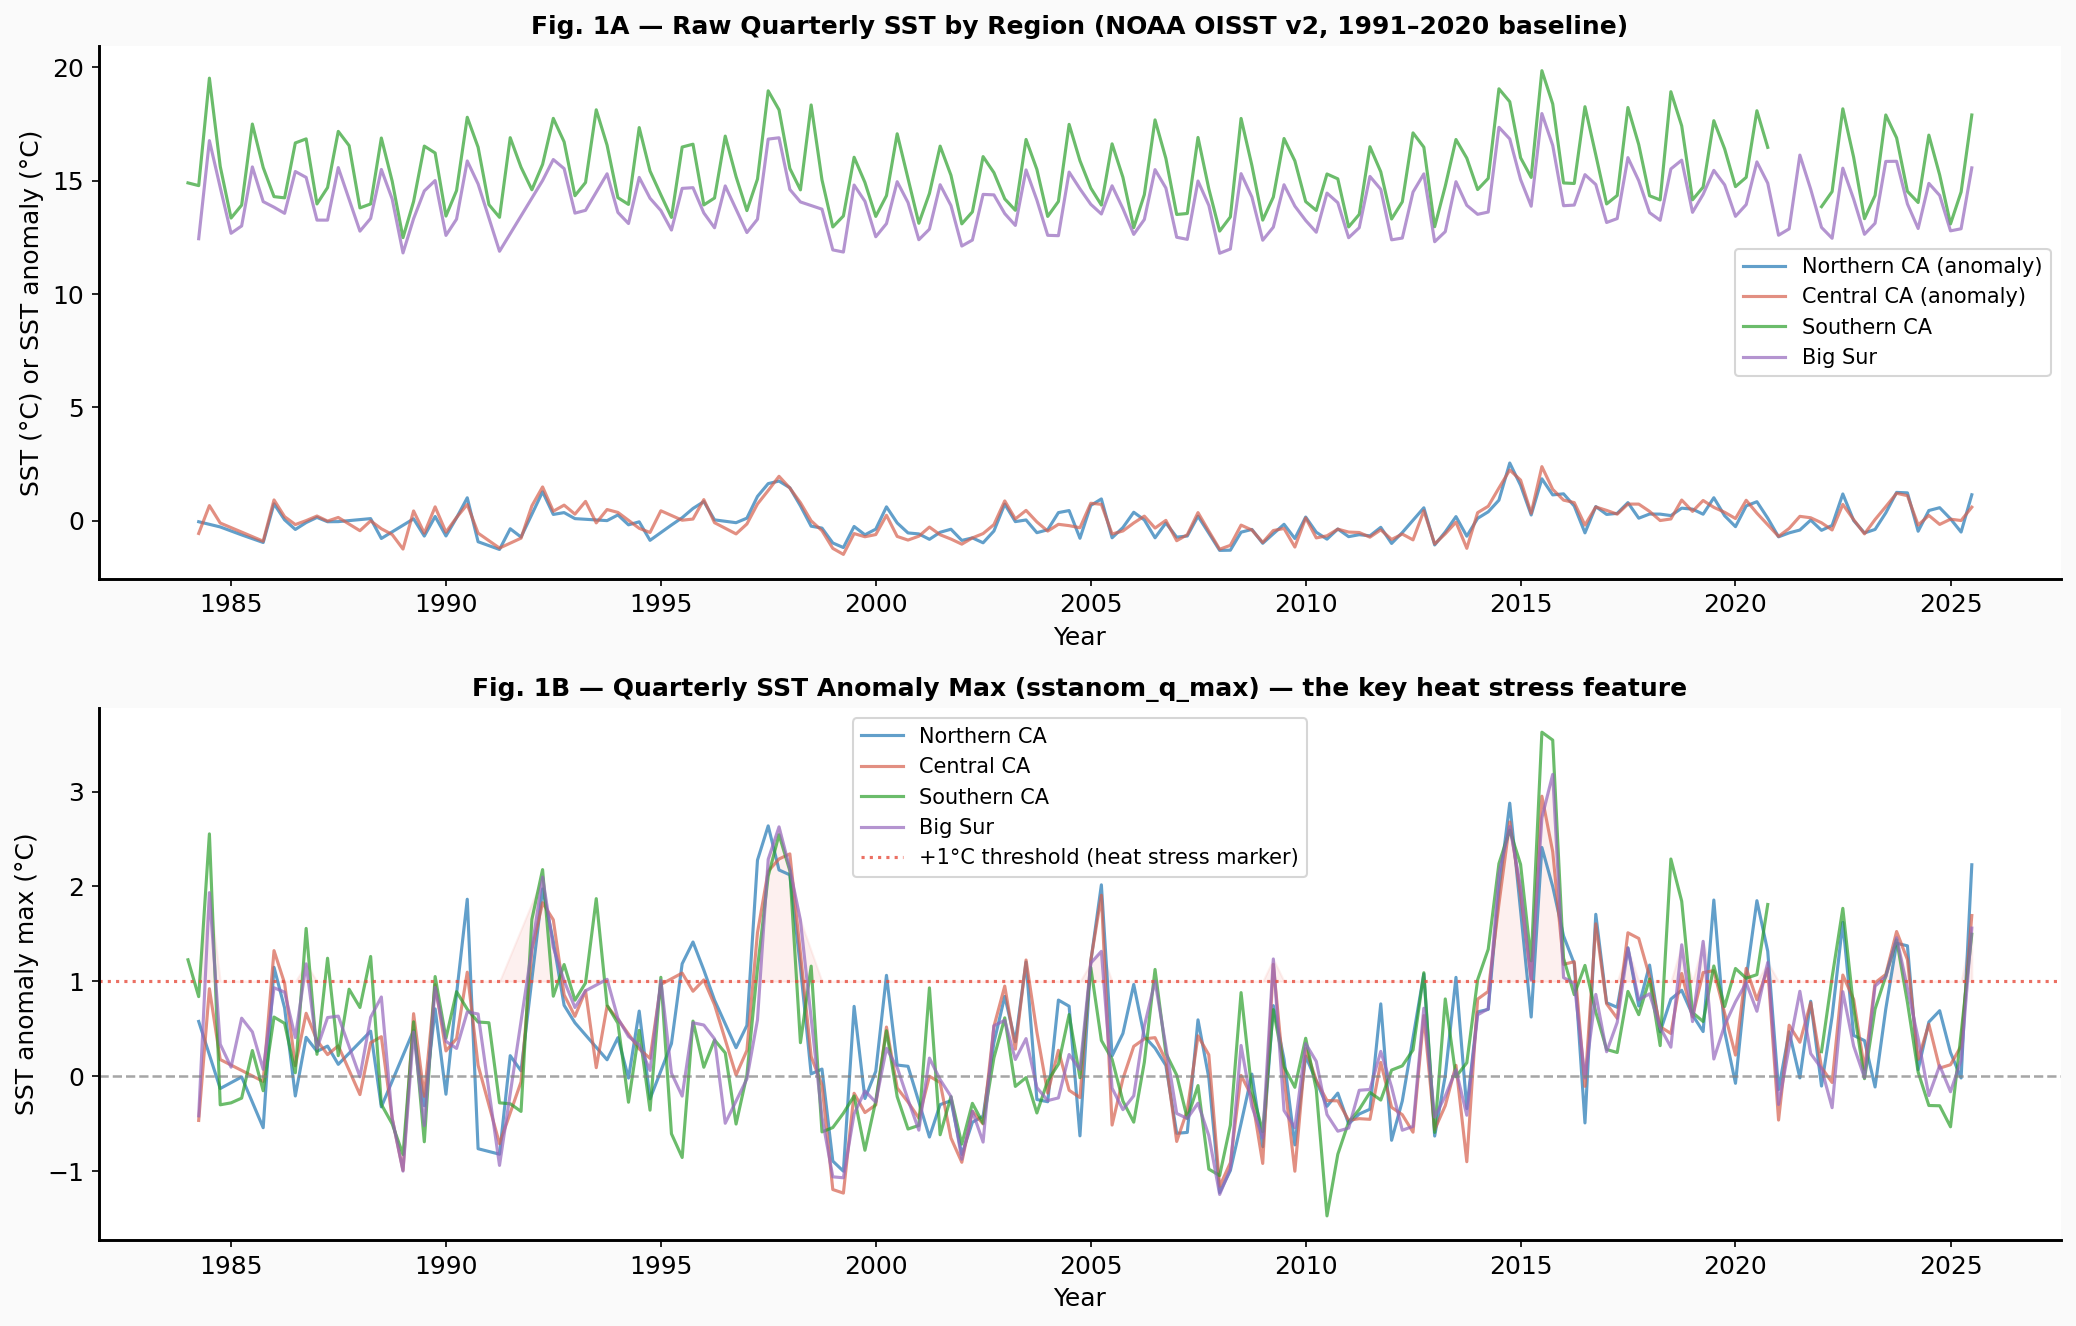

Saved: ../../5_FIGURES/sst_pipeline/sst_fig1_raw_and_anomaly.png


In [3]:
# ============================================================
# CELL 3: FIGURE 1 — RAW SST TIME SERIES (all regions)
# Reproduces your "Raw SST data (quarterly)" panel
# but shows all 4 regions + anomaly on same figure
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.patch.set_facecolor('#fafafa')

# Panel 1: Raw quarterly SST mean
ax1 = axes[0]
sst_col_candidates = ['sst_q_mean', 'sstanom_q_mean']

for region, df in region_dfs.items():
    # Find the raw SST column (not anomaly)
    raw_col = next((c for c in df.columns if c == 'sst_q_mean'), None)
    if raw_col is None:
        # Fall back: if only anomaly available, note it
        anom_col = next((c for c in df.columns if c == 'sstanom_q_mean'), None)
        if anom_col:
            ax1.plot(df.index, df[anom_col], alpha=0.7, lw=1.5,
                     color=REGION_COLORS[region], label=f'{REGION_NAMES[region]} (anomaly)')
    else:
        ax1.plot(df.index, df[raw_col], alpha=0.7, lw=1.5,
                 color=REGION_COLORS[region], label=REGION_NAMES[region])

ax1.set_ylabel('SST (°C) or SST anomaly (°C)')
ax1.set_title('Fig. 1A — Raw Quarterly SST by Region (NOAA OISST v2, 1991–2020 baseline)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlabel('Year')

# Panel 2: SST anomaly max (the actual feature used)
ax2 = axes[1]
for region, df in region_dfs.items():
    anom_col = next((c for c in ['sstanom_q_max','sstanom_q_mean'] if c in df.columns), None)
    if anom_col is None: continue
    ax2.plot(df.index, df[anom_col], alpha=0.7, lw=1.5,
             color=REGION_COLORS[region], label=REGION_NAMES[region])

ax2.axhline(0, linestyle='--', color='gray', lw=1.2, alpha=0.7)
ax2.axhline(1.0, linestyle=':', color='#e74c3c', lw=1.5, alpha=0.8,
            label='+1°C threshold (heat stress marker)')
ax2.fill_between(df.index, 1.0, df[anom_col].clip(lower=1.0),
                 alpha=0.08, color='#e74c3c')
ax2.set_ylabel('SST anomaly max (°C)')
ax2.set_title('Fig. 1B — Quarterly SST Anomaly Max (sstanom_q_max) — the key heat stress feature',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlabel('Year')

fig.tight_layout()
out = FIG_DIR / 'sst_fig1_raw_and_anomaly.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

---
## Step 3 — Quarterly Feature Engineering

Monthly SST anomalies are aggregated to match the quarterly kelp time series.
Four features are computed per quarter:

| Feature | Formula | Ecological meaning |
|---------|---------|--------------------|
| `sstanom_q_mean` | Mean of 3 monthly anomalies | Average thermal stress across quarter |
| `sstanom_q_max` | Max of 3 monthly anomalies | Peak heat event intensity |
| `sstanom_pos_sum` | Sum of positive anomalies only | Cumulative heat loading (°C·months) |
| `sstanom_exceed_months` | Count of months > +1°C | Duration of significant heat stress |

**Why `sstanom_q_max` is the best predictor:**
Kelp physiology responds more to *peak* temperature than *average* temperature. Giant kelp (*Macrocystis pyrifera*) photosynthesis and growth rates decline sharply above 20–22°C. A single month of extreme heat can trigger blade shedding even if the rest of the quarter is normal. `sstanom_q_max` captures this threshold behavior better than the mean.

In [4]:
# ============================================================
# CELL 4: BLOCK BOOTSTRAP HELPER
# ============================================================
def block_bootstrap_auc(score, y, block_len=4, B=2000, seed=42):
    score = np.asarray(score, dtype=float)
    y     = np.asarray(y, dtype=int)
    n     = len(y)
    starts   = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng      = np.random.default_rng(seed)
    aucs = []
    for _ in range(B):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx    = np.concatenate([np.arange(s, s+block_len) for s in chosen])[:n]
        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2: continue
        aucs.append(roc_auc_score(yb, sb))
    aucs = np.array(aucs)
    return {'auc': aucs.mean(), 'ci_lo': np.quantile(aucs, 0.025),
            'ci_hi': np.quantile(aucs, 0.975), 'n': len(aucs)}

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return '(ns)'

def styled_table(ax, df_table, title, header_color='#1a3a5c',
                 highlight_rows=None, highlight_color='#d5e8d4'):
    ax.axis('off')
    tbl = ax.table(
        cellText=df_table.values.tolist(),
        colLabels=df_table.columns.tolist(),
        cellLoc='center', loc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10.5)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#b0bec5')
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold', fontsize=11)
        else:
            dr = row - 1
            if highlight_rows and dr in highlight_rows:
                cell.set_facecolor(highlight_color)
            elif dr % 2 == 0:
                cell.set_facecolor('#f5f7fa')
            else:
                cell.set_facecolor('#ffffff')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=14, color='#1a3a5c')
    return tbl

print('✓ Helpers ready.')

✓ Helpers ready.


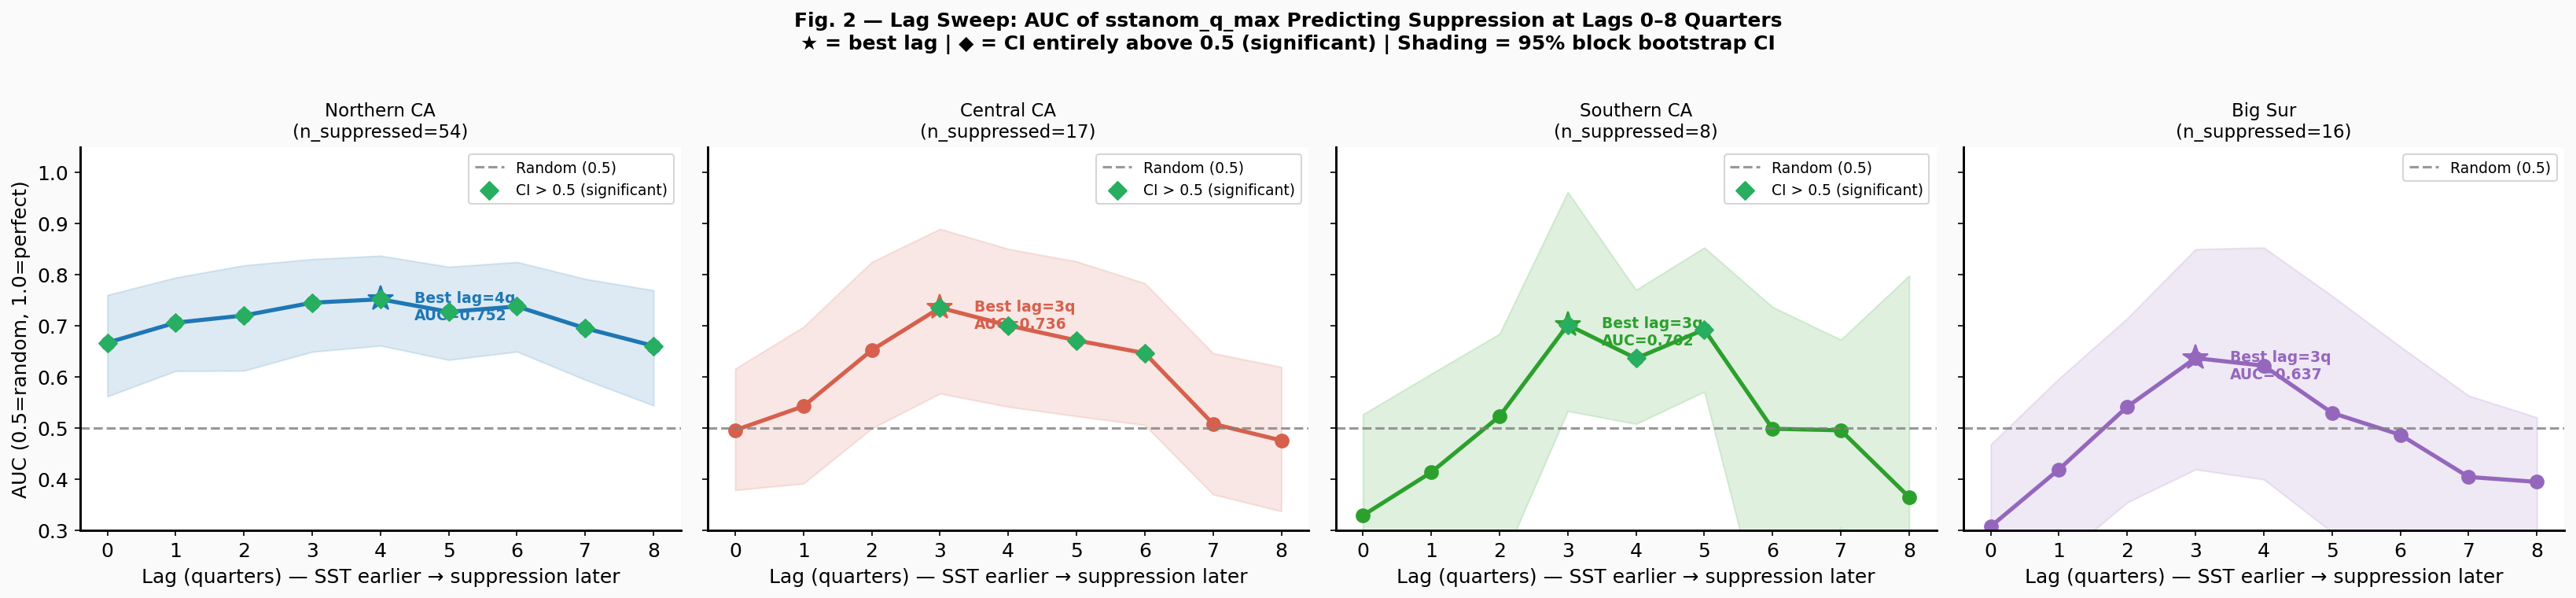

Saved: ../../5_FIGURES/sst_pipeline/sst_fig2_lag_sweep.png

=== Best lag per region ===
  Northern CA    : lag=4q AUC=0.752 CI=[0.662,0.837]
  Central CA     : lag=3q AUC=0.736 CI=[0.568,0.890]
  Southern CA    : lag=3q AUC=0.702 CI=[0.533,0.962]
  Big Sur        : lag=3q AUC=0.637 CI=[0.419,0.850]


In [5]:
# ============================================================
# CELL 5: FIGURE 2 — LAG SWEEP
# Reproduces your "AUC vs lag" figure for all regions
# Tests lags 0–8 quarters for sstanom_q_max → suppressed
# ============================================================
LAGS = range(0, 9)
SST_SCORE_COL = 'sstanom_q_max'  # best single predictor

lag_results = []

for region, df in region_dfs.items():
    if SST_SCORE_COL not in df.columns:
        # try fallback
        SST_SCORE_COL = next((c for c in df.columns if 'sstanom' in c), None)
    if SST_SCORE_COL is None:
        print(f'  {region}: no SST anomaly column found')
        continue

    y = df['suppressed'].astype(int)

    for lag in LAGS:
        score = df[SST_SCORE_COL].shift(lag)
        tmp   = pd.DataFrame({'s': score, 'y': y}).dropna()
        if tmp['y'].nunique() < 2: continue

        out  = block_bootstrap_auc(tmp['s'], tmp['y'], block_len=4, B=2000, seed=42)
        rpb, p_rpb = pointbiserialr(tmp['y'], tmp['s'])

        lag_results.append({
            'region':  region,
            'lag':     lag,
            'n':       len(tmp),
            'n_supp':  int(tmp['y'].sum()),
            'auc':     out['auc'],
            'ci_lo':   out['ci_lo'],
            'ci_hi':   out['ci_hi'],
            'rpb':     rpb,
            'p_rpb':   p_rpb,
        })

lag_df = pd.DataFrame(lag_results)

# --- Plot ---
fig, axes = plt.subplots(1, len(region_dfs), figsize=(5.5*len(region_dfs), 5), sharey=True)
if len(region_dfs) == 1: axes = [axes]
fig.patch.set_facecolor('#fafafa')

for ax, (region, df) in zip(axes, region_dfs.items()):
    sub = lag_df[lag_df['region'] == region]
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
        continue
    c = REGION_COLORS[region]

    ax.plot(sub['lag'], sub['auc'], marker='o', markersize=8, color=c, lw=2.5)
    ax.fill_between(sub['lag'], sub['ci_lo'], sub['ci_hi'], alpha=0.15, color=c)
    ax.axhline(0.5, linestyle='--', color='gray', lw=1.5, alpha=0.8, label='Random (0.5)')

    # Mark best lag
    best = sub.loc[sub['auc'].idxmax()]
    ax.plot(best['lag'], best['auc'], marker='*', markersize=16, color=c, zorder=5)
    ax.annotate(f"Best lag={int(best['lag'])}q\nAUC={best['auc']:.3f}",
                xy=(best['lag'], best['auc']),
                xytext=(best['lag']+0.5, best['auc']-0.04),
                fontsize=9, color=c, fontweight='bold')

    # Mark significant lags (CI > 0.5)
    sig = sub[sub['ci_lo'] > 0.5]
    if not sig.empty:
        ax.scatter(sig['lag'], sig['auc'], marker='D', s=60,
                   color='#27ae60', zorder=6, label='CI > 0.5 (significant)')

    ax.set_title(f'{REGION_NAMES[region]}\n(n_suppressed={int(sub["n_supp"].iloc[0])})',
                 fontsize=11)
    ax.set_xlabel('Lag (quarters) — SST earlier → suppression later')
    if ax == axes[0]: ax.set_ylabel('AUC (0.5=random, 1.0=perfect)')
    ax.set_ylim(0.3, 1.05)
    ax.set_xticks(list(LAGS))
    ax.legend(fontsize=9)

fig.suptitle(
    f'Fig. 2 — Lag Sweep: AUC of {SST_SCORE_COL} Predicting Suppression at Lags 0–8 Quarters\n'
    '★ = best lag | ◆ = CI entirely above 0.5 (significant) | Shading = 95% block bootstrap CI',
    fontsize=12, y=1.01, fontweight='bold'
)
fig.tight_layout()
out = FIG_DIR / 'sst_fig2_lag_sweep.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# Print best lag per region
print('\n=== Best lag per region ===')
for region in region_dfs:
    sub = lag_df[lag_df['region'] == region]
    if sub.empty: continue
    best = sub.loc[sub['auc'].idxmax()]
    print(f'  {REGION_NAMES[region]:15s}: lag={int(best["lag"])}q '
          f'AUC={best["auc"]:.3f} CI=[{best["ci_lo"]:.3f},{best["ci_hi"]:.3f}]')

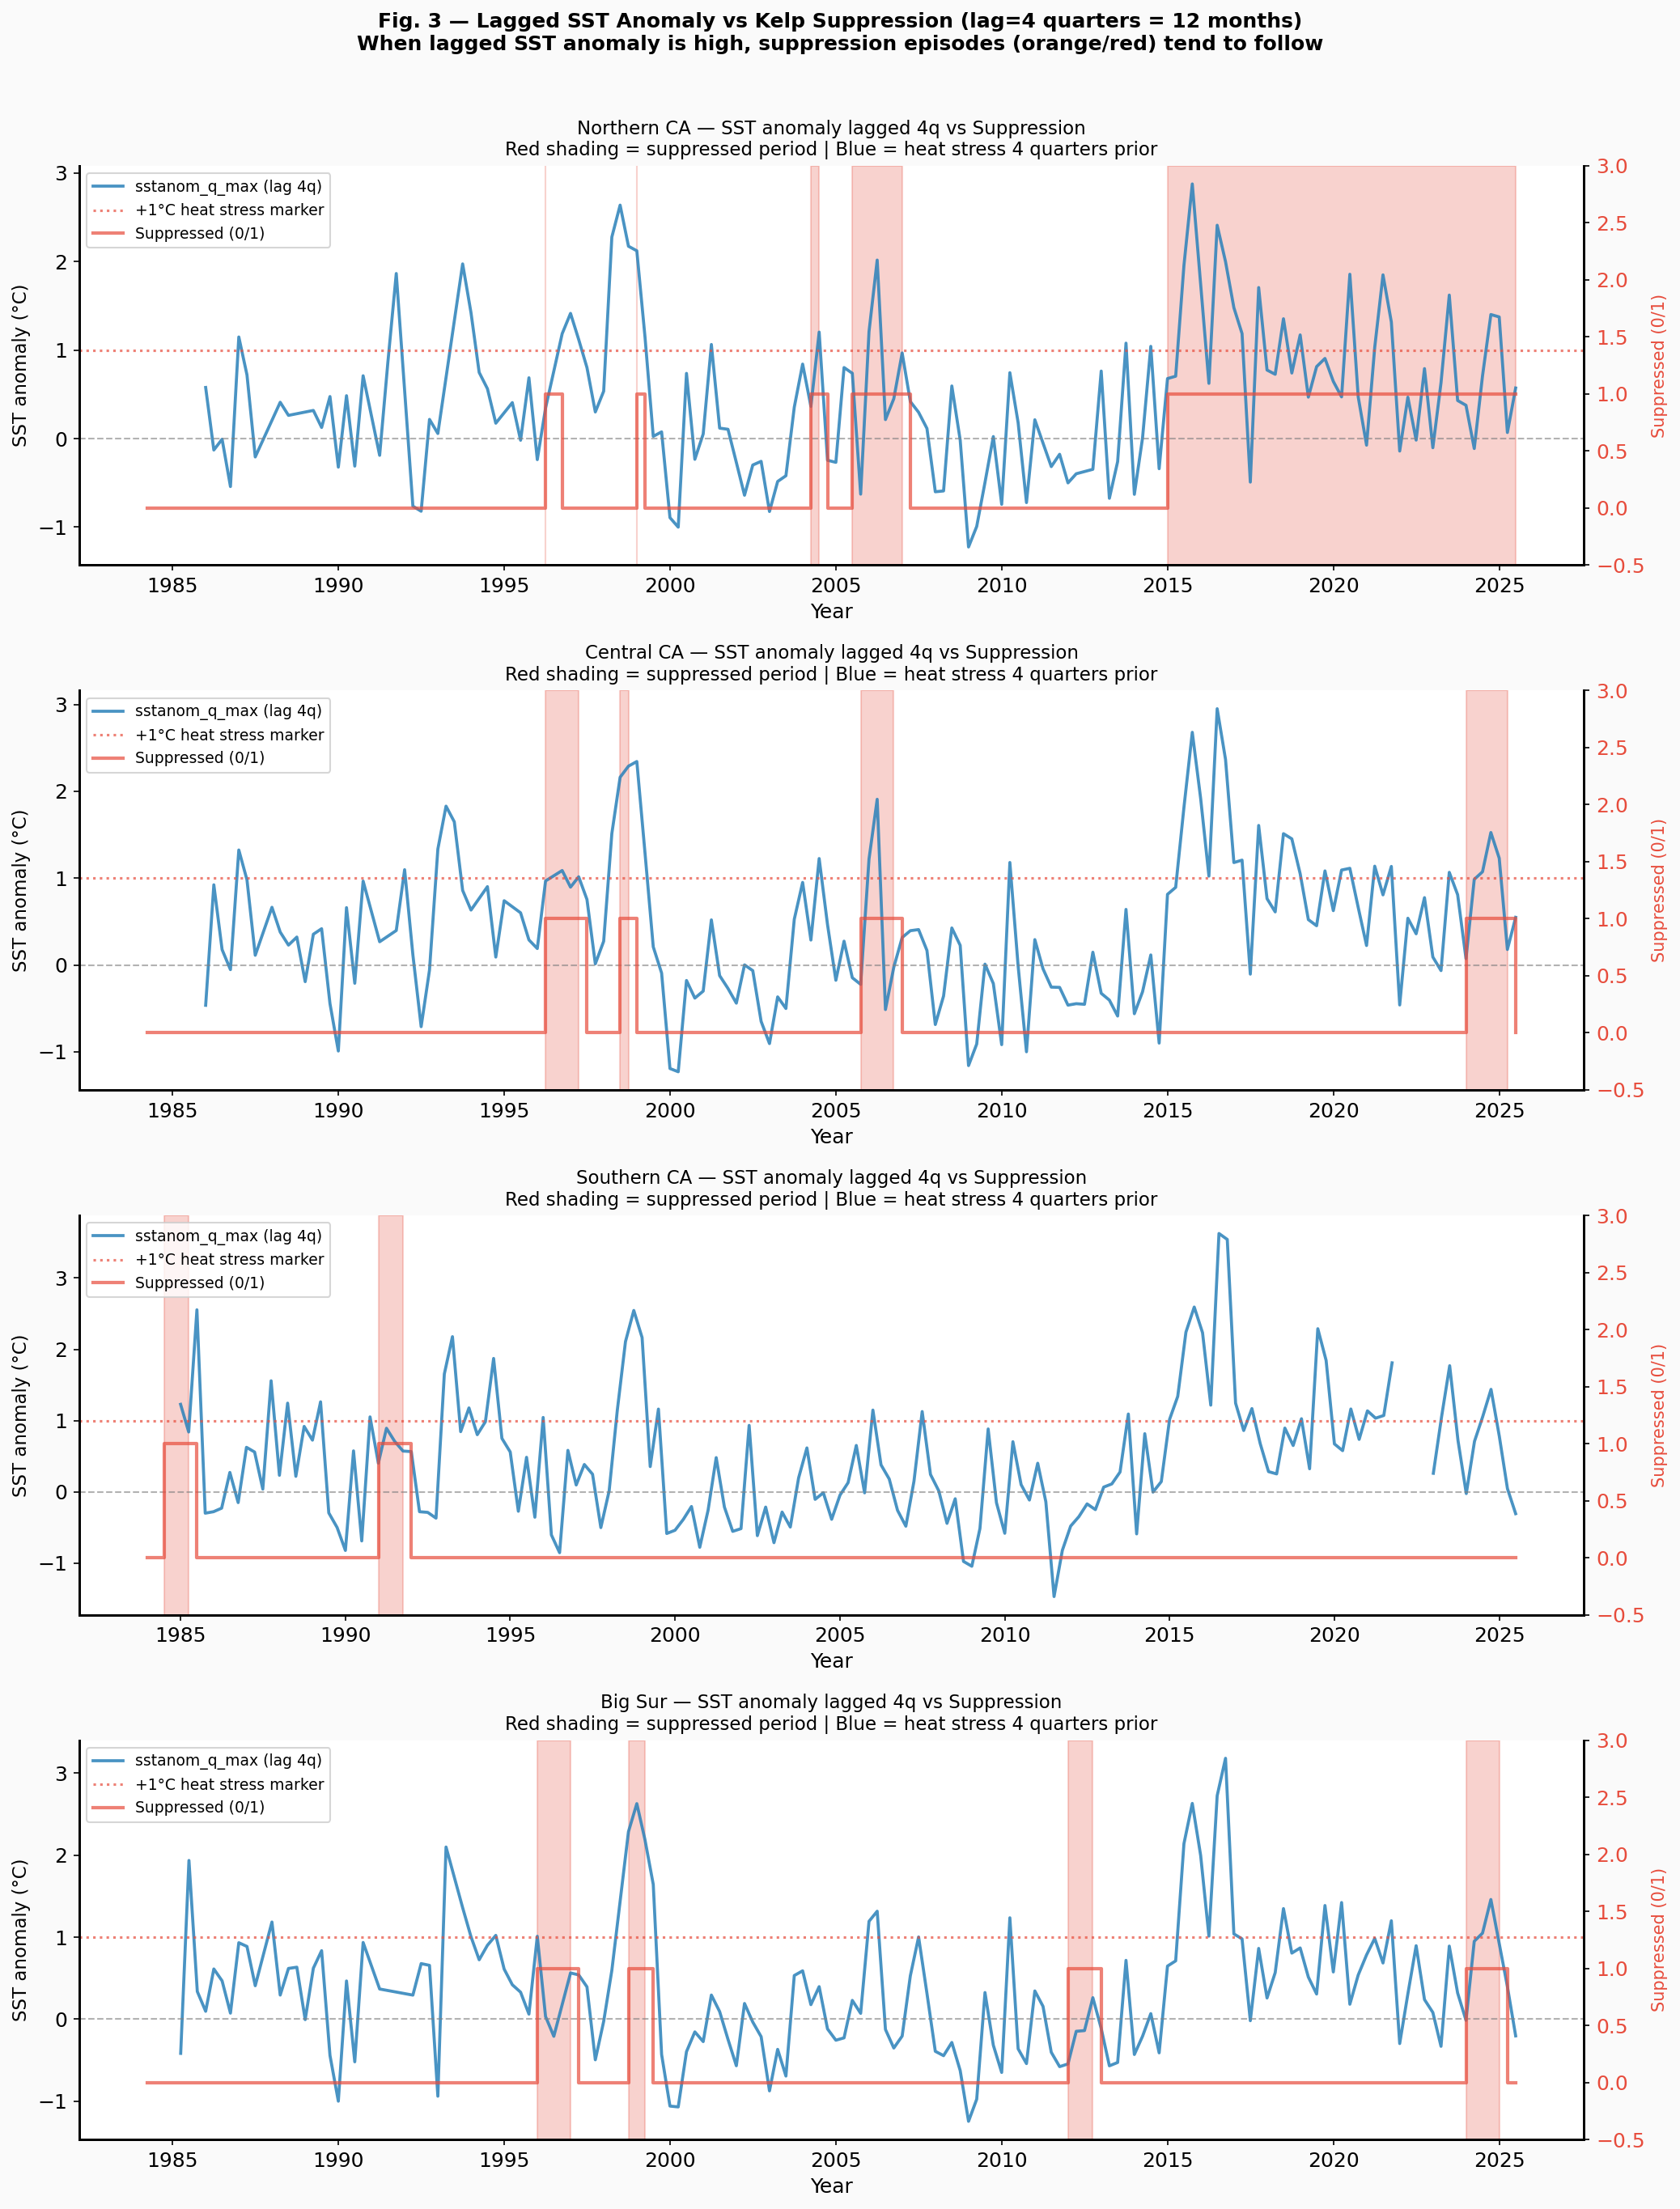

Saved: ../../5_FIGURES/sst_pipeline/sst_fig3_lagged_overlay.png


In [6]:
# ============================================================
# CELL 6: FIGURE 3 — LAGGED SST OVERLAY vs SUPPRESSION
# Reproduces your bottom panel — SST anomaly (shifted by best
# lag) plotted against the suppressed 0/1 label
# ============================================================
BEST_LAG = 4   # matches heat_lag4 used in ML model — update if your sweep shows different

fig, axes = plt.subplots(len(region_dfs), 1,
                          figsize=(14, 4.5*len(region_dfs)), sharex=False)
if len(region_dfs) == 1: axes = [axes]
fig.patch.set_facecolor('#fafafa')

for ax, (region, df) in zip(axes, region_dfs.items()):
    sst_col = next((c for c in ['sstanom_q_max','sstanom_q_mean'] if c in df.columns), None)
    if sst_col is None:
        ax.text(0.5, 0.5, 'No SST column', ha='center', transform=ax.transAxes)
        continue

    sst_lagged  = df[sst_col].shift(BEST_LAG)
    suppressed  = df['suppressed'].astype(int)
    c           = REGION_COLORS[region]

    # Plot SST anomaly
    ax.plot(df.index, sst_lagged, color='#2980b9', lw=1.8, alpha=0.85,
            label=f'{sst_col} (lag {BEST_LAG}q)')
    ax.axhline(0, linestyle='--', color='gray', lw=1, alpha=0.6)
    ax.axhline(1.0, linestyle=':', color='#e74c3c', lw=1.5, alpha=0.7,
               label='+1°C heat stress marker')

    # Shade when suppressed
    for _, grp in suppressed[suppressed==1].groupby((suppressed!=suppressed.shift()).cumsum()):
        ax.axvspan(grp.index[0], grp.index[-1], alpha=0.25, color='#e74c3c', zorder=0)

    # Overlay suppression as step function on secondary axis
    ax2 = ax.twinx()
    ax2.step(df.index, suppressed, color='#e74c3c', lw=2, alpha=0.7,
             where='post', label='Suppressed (0/1)')
    ax2.set_ylabel('Suppressed (0/1)', color='#e74c3c', fontsize=10)
    ax2.set_ylim(-0.5, 3)
    ax2.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.spines['right'].set_visible(True)

    ax.set_title(f'{REGION_NAMES[region]} — SST anomaly lagged {BEST_LAG}q vs Suppression\n'
                 f'Red shading = suppressed period | Blue = heat stress {BEST_LAG} quarters prior',
                 fontsize=11)
    ax.set_ylabel('SST anomaly (°C)', fontsize=11)
    ax.set_xlabel('Year')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')

fig.suptitle(
    f'Fig. 3 — Lagged SST Anomaly vs Kelp Suppression (lag={BEST_LAG} quarters = {BEST_LAG*3} months)\n'
    'When lagged SST anomaly is high, suppression episodes (orange/red) tend to follow',
    fontsize=12, y=1.01, fontweight='bold'
)
fig.tight_layout()
out = FIG_DIR / 'sst_fig3_lagged_overlay.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

---
## Step 5 — Statistical Significance Tables

Three independent statistical tests are used to confirm that the SST lag relationship is real:

| Test | What it asks | Why it's appropriate |
|------|-------------|---------------------|
| **Block bootstrap AUC** | Does SST at lag L rank suppressed quarters above non-suppressed? | Accounts for temporal autocorrelation; the primary test |
| **Point-biserial r** | Is SST anomaly linearly correlated with the suppression label? | Classic continuous-vs-binary correlation; assumes independence (shows size of effect) |
| **Mann-Whitney U** | Is SST anomaly distribution higher during suppressed vs non-suppressed quarters? | Non-parametric; no normality assumption; tests distributional shift |

All three converging on the same lag confirms the result is not an artifact of any single test.

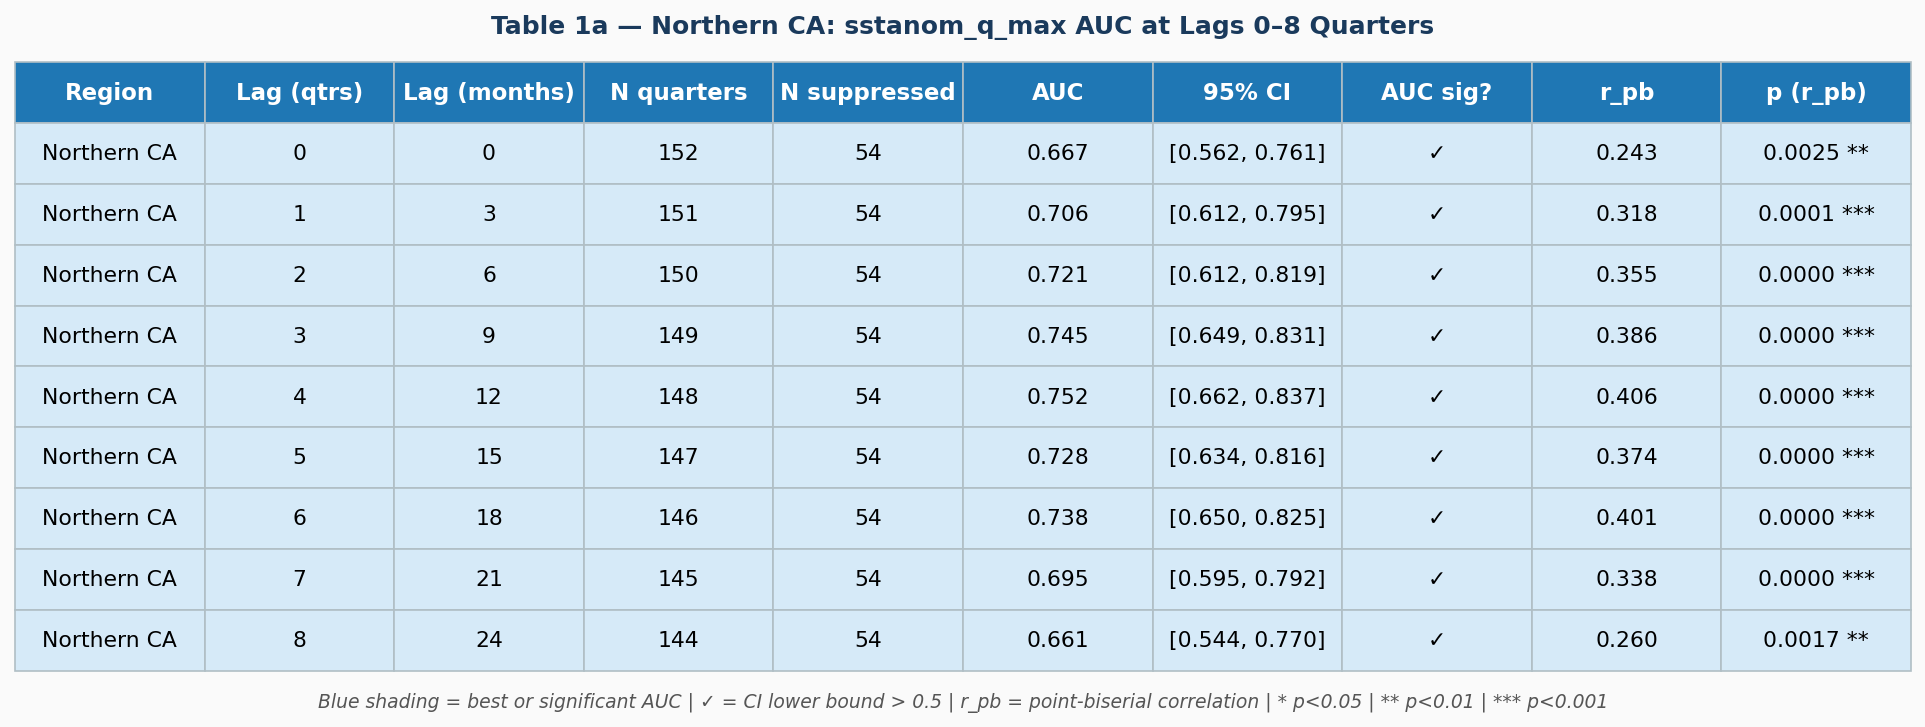

Saved: ../../5_FIGURES/sst_pipeline/sst_T1a_lag_sweep_norcal.png


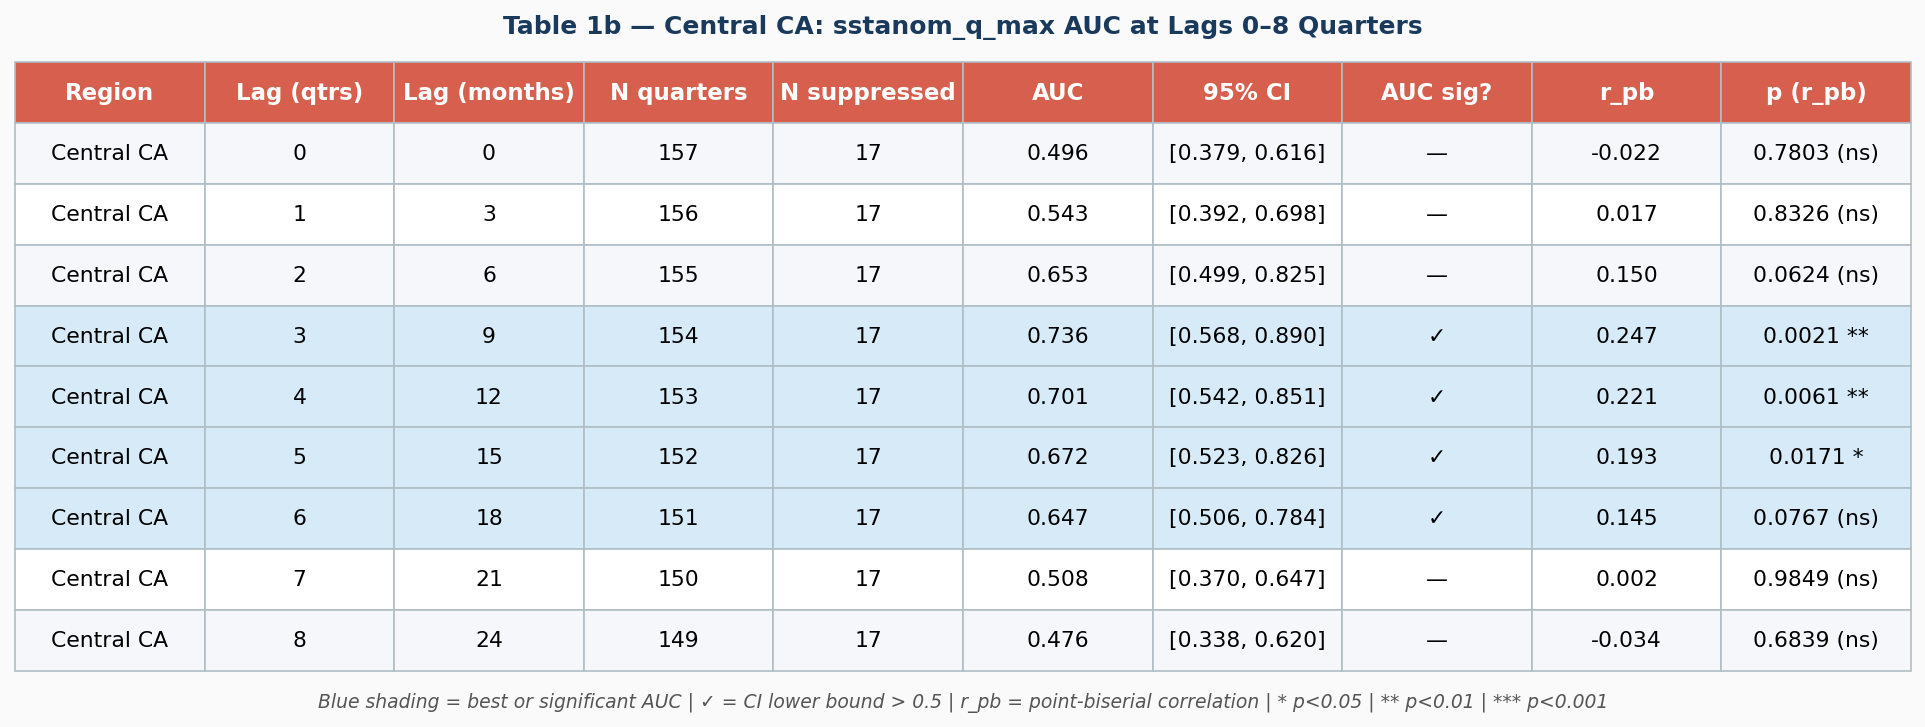

Saved: ../../5_FIGURES/sst_pipeline/sst_T1b_lag_sweep_midcal.png


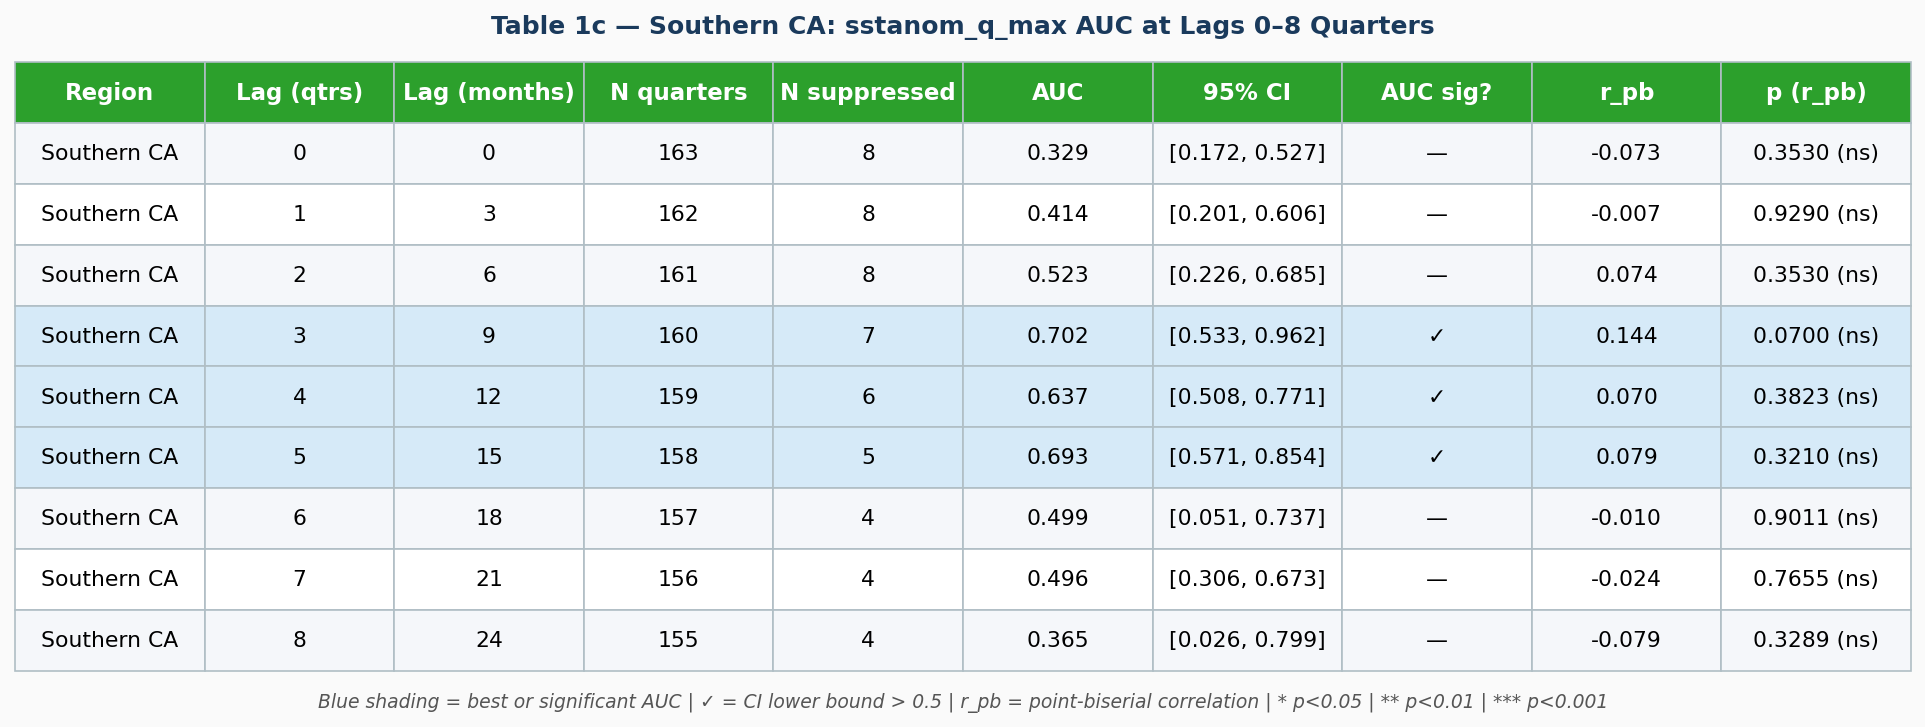

Saved: ../../5_FIGURES/sst_pipeline/sst_T1c_lag_sweep_socal.png


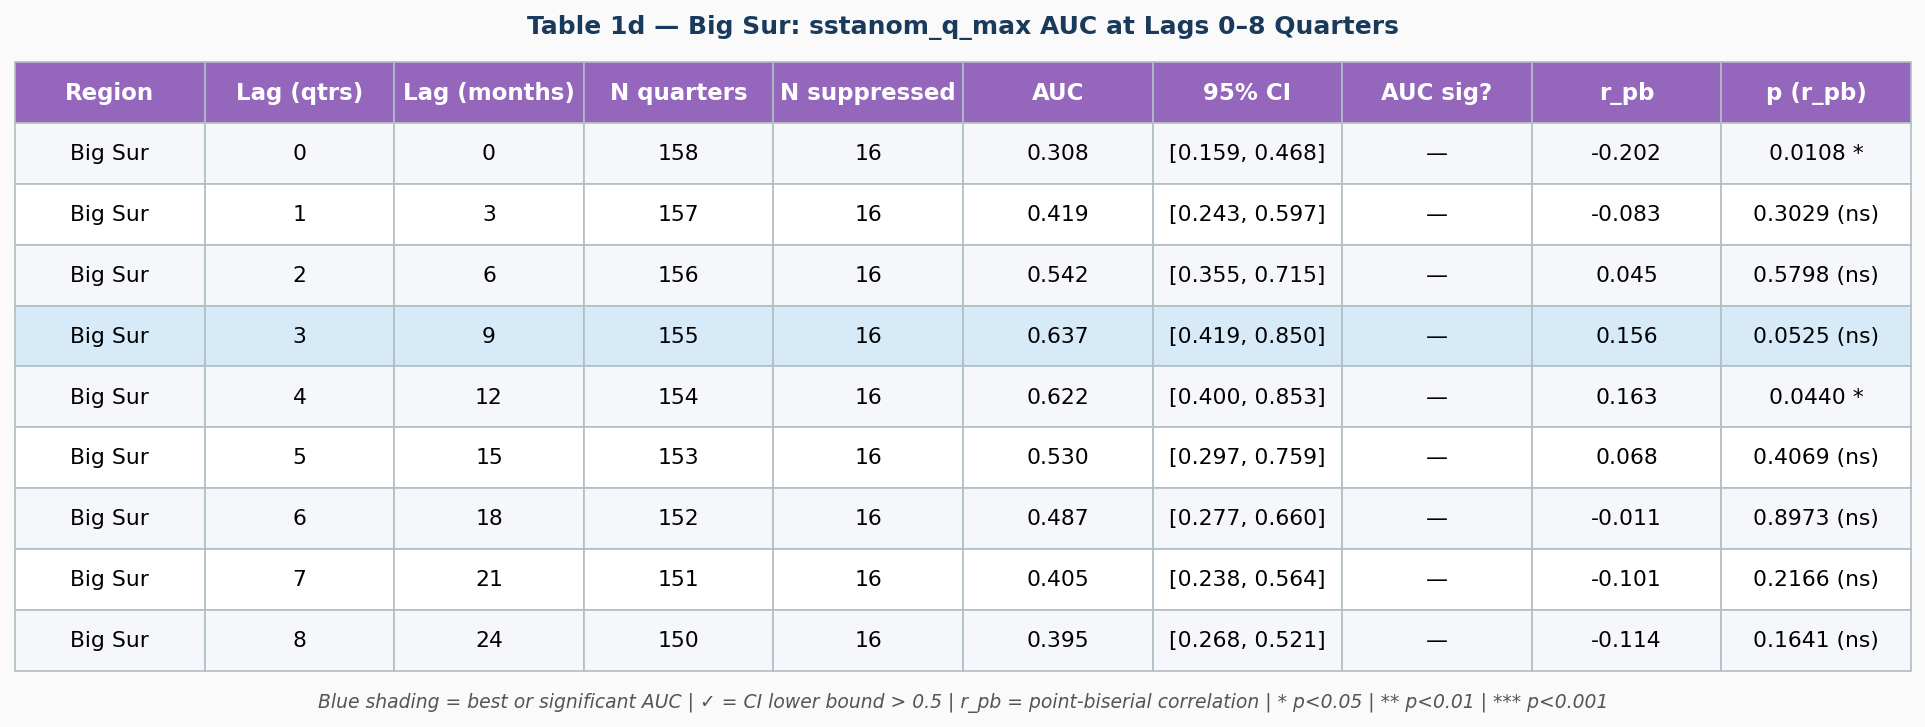

Saved: ../../5_FIGURES/sst_pipeline/sst_T1d_lag_sweep_bigsur.png


In [7]:
# ============================================================
# CELL 7: TABLE 1 — LAG SWEEP FULL RESULTS
# Block bootstrap AUC at every lag for every region
# ============================================================
t1_rows = []
for _, row in lag_df.iterrows():
    sig_auc = row['ci_lo'] > 0.5
    sig_rpb = row['p_rpb'] < 0.05
    t1_rows.append({
        'Region':        REGION_NAMES[row['region']],
        'Lag (qtrs)':    int(row['lag']),
        'Lag (months)':  int(row['lag'] * 3),
        'N quarters':    int(row['n']),
        'N suppressed':  int(row['n_supp']),
        'AUC':           f"{row['auc']:.3f}",
        '95% CI':        f"[{row['ci_lo']:.3f}, {row['ci_hi']:.3f}]",
        'AUC sig?':      '✓' if sig_auc else '—',
        'r_pb':          f"{row['rpb']:.3f}",
        'p (r_pb)':      f"{row['p_rpb']:.4f} {sig_stars(row['p_rpb'])}",
    })

t1_df = pd.DataFrame(t1_rows)

# Highlight rows where AUC is significant
highlight_t1 = [i for i,r in enumerate(t1_rows) if r['AUC sig?'] == '✓']
# Also highlight best lag per region
best_lags = lag_df.loc[lag_df.groupby('region')['auc'].idxmax()]
best_idx  = [
    i for i, r in enumerate(t1_rows)
    if any(
        r['Region'] == REGION_NAMES[bl['region']] and int(r['Lag (qtrs)']) == int(bl['lag'])
        for _, bl in best_lags.iterrows()
    )
]

# Show per-region tables (one per region so it fits)
for region in region_dfs:
    sub = t1_df[t1_df['Region'] == REGION_NAMES[region]].reset_index(drop=True)
    if sub.empty: continue
    hl = [i for i, r in sub.iterrows() if r['AUC sig?'] == '✓']
    best_i = sub['AUC'].apply(float).idxmax()
    hl = list(set(hl + [best_i]))

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#fafafa')
    styled_table(ax, sub,
        title=f'Table 1{"abcd"[list(region_dfs.keys()).index(region)]} — '
              f'{REGION_NAMES[region]}: sstanom_q_max AUC at Lags 0–8 Quarters',
        header_color=REGION_COLORS[region].replace('#','#').rstrip(),
        highlight_rows=hl,
        highlight_color='#d6eaf8')
    ax.text(0.5, -0.06,
        'Blue shading = best or significant AUC | ✓ = CI lower bound > 0.5 | '
        'r_pb = point-biserial correlation | * p<0.05 | ** p<0.01 | *** p<0.001',
        transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
    fig.tight_layout()
    out = FIG_DIR / f'sst_T1{"abcd"[list(region_dfs.keys()).index(region)]}_lag_sweep_{region}.png'
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
    plt.show()
    print(f'Saved: {out}')

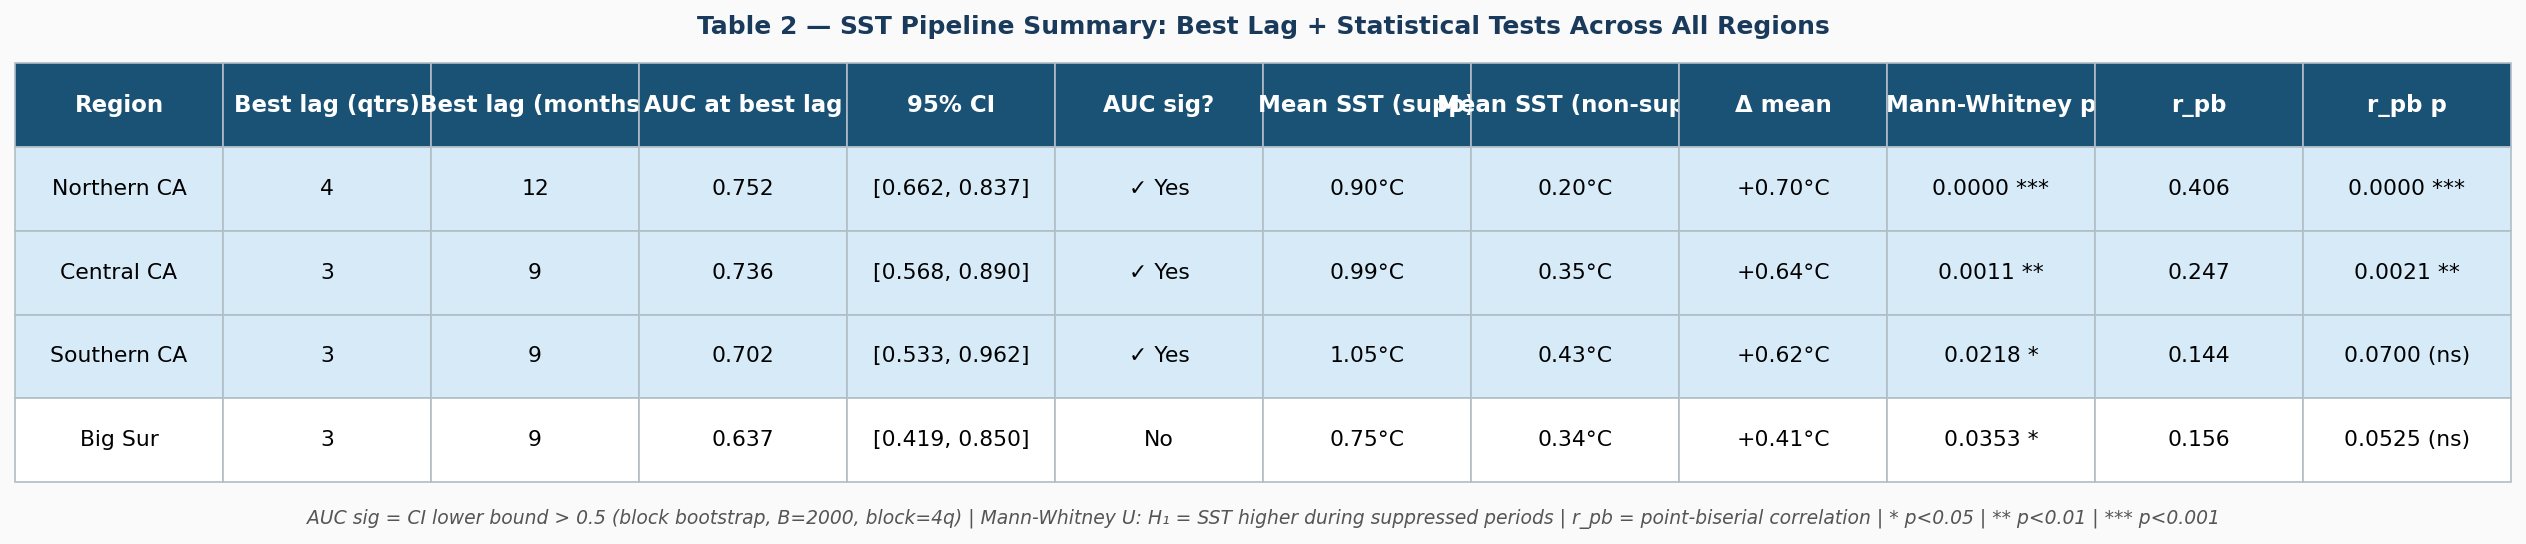

Saved: ../../5_FIGURES/sst_pipeline/sst_T2_best_lag_summary.png

=== TABLE 2 SUMMARY ===
     Region  Best lag (qtrs)  Best lag (months) AUC at best lag         95% CI AUC sig? Mean SST (supp) Mean SST (non-supp)  Δ mean Mann-Whitney p  r_pb      r_pb p
Northern CA                4                 12           0.752 [0.662, 0.837]    ✓ Yes          0.90°C              0.20°C +0.70°C     0.0000 *** 0.406  0.0000 ***
 Central CA                3                  9           0.736 [0.568, 0.890]    ✓ Yes          0.99°C              0.35°C +0.64°C      0.0011 ** 0.247   0.0021 **
Southern CA                3                  9           0.702 [0.533, 0.962]    ✓ Yes          1.05°C              0.43°C +0.62°C       0.0218 * 0.144 0.0700 (ns)
    Big Sur                3                  9           0.637 [0.419, 0.850]       No          0.75°C              0.34°C +0.41°C       0.0353 * 0.156 0.0525 (ns)


In [8]:
# ============================================================
# CELL 8: TABLE 2 — BEST LAG SUMMARY + MANN-WHITNEY
# Cross-region summary at each region's optimal lag
# Includes Mann-Whitney U test comparing SST distributions
# ============================================================
t2_rows = []

for region, df in region_dfs.items():
    sst_col = next((c for c in ['sstanom_q_max','sstanom_q_mean'] if c in df.columns), None)
    if sst_col is None: continue

    sub = lag_df[lag_df['region'] == region]
    if sub.empty: continue
    best = sub.loc[sub['auc'].idxmax()]
    best_lag = int(best['lag'])

    # At best lag
    sst_shifted = df[sst_col].shift(best_lag)
    y           = df['suppressed'].astype(int)
    tmp         = pd.DataFrame({'sst': sst_shifted, 'y': y}).dropna()

    supp_sst     = tmp[tmp['y']==1]['sst']
    non_supp_sst = tmp[tmp['y']==0]['sst']

    u_stat, p_mwu = mannwhitneyu(supp_sst, non_supp_sst, alternative='greater')
    rpb, p_rpb    = pointbiserialr(tmp['y'], tmp['sst'])

    t2_rows.append({
        'Region':              REGION_NAMES[region],
        'Best lag (qtrs)':     best_lag,
        'Best lag (months)':   best_lag * 3,
        'AUC at best lag':     f"{best['auc']:.3f}",
        '95% CI':              f"[{best['ci_lo']:.3f}, {best['ci_hi']:.3f}]",
        'AUC sig?':            '✓ Yes' if best['ci_lo'] > 0.5 else 'No',
        'Mean SST (supp)':     f"{supp_sst.mean():.2f}°C",
        'Mean SST (non-supp)': f"{non_supp_sst.mean():.2f}°C",
        'Δ mean':              f"{supp_sst.mean() - non_supp_sst.mean():+.2f}°C",
        'Mann-Whitney p':      f"{p_mwu:.4f} {sig_stars(p_mwu)}",
        'r_pb':                f"{rpb:.3f}",
        'r_pb p':              f"{p_rpb:.4f} {sig_stars(p_rpb)}",
    })

t2_df = pd.DataFrame(t2_rows)
highlight_t2 = [i for i,r in enumerate(t2_rows) if r['AUC sig?'].startswith('✓')]

fig, ax = plt.subplots(figsize=(17, 3.8))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t2_df,
    title='Table 2 — SST Pipeline Summary: Best Lag + Statistical Tests Across All Regions',
    header_color='#1a5276',
    highlight_rows=highlight_t2,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.10,
    'AUC sig = CI lower bound > 0.5 (block bootstrap, B=2000, block=4q) | '
    'Mann-Whitney U: H₁ = SST higher during suppressed periods | '
    'r_pb = point-biserial correlation | * p<0.05 | ** p<0.01 | *** p<0.001',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'sst_T2_best_lag_summary.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')
print('\n=== TABLE 2 SUMMARY ===')
print(t2_df.to_string(index=False))

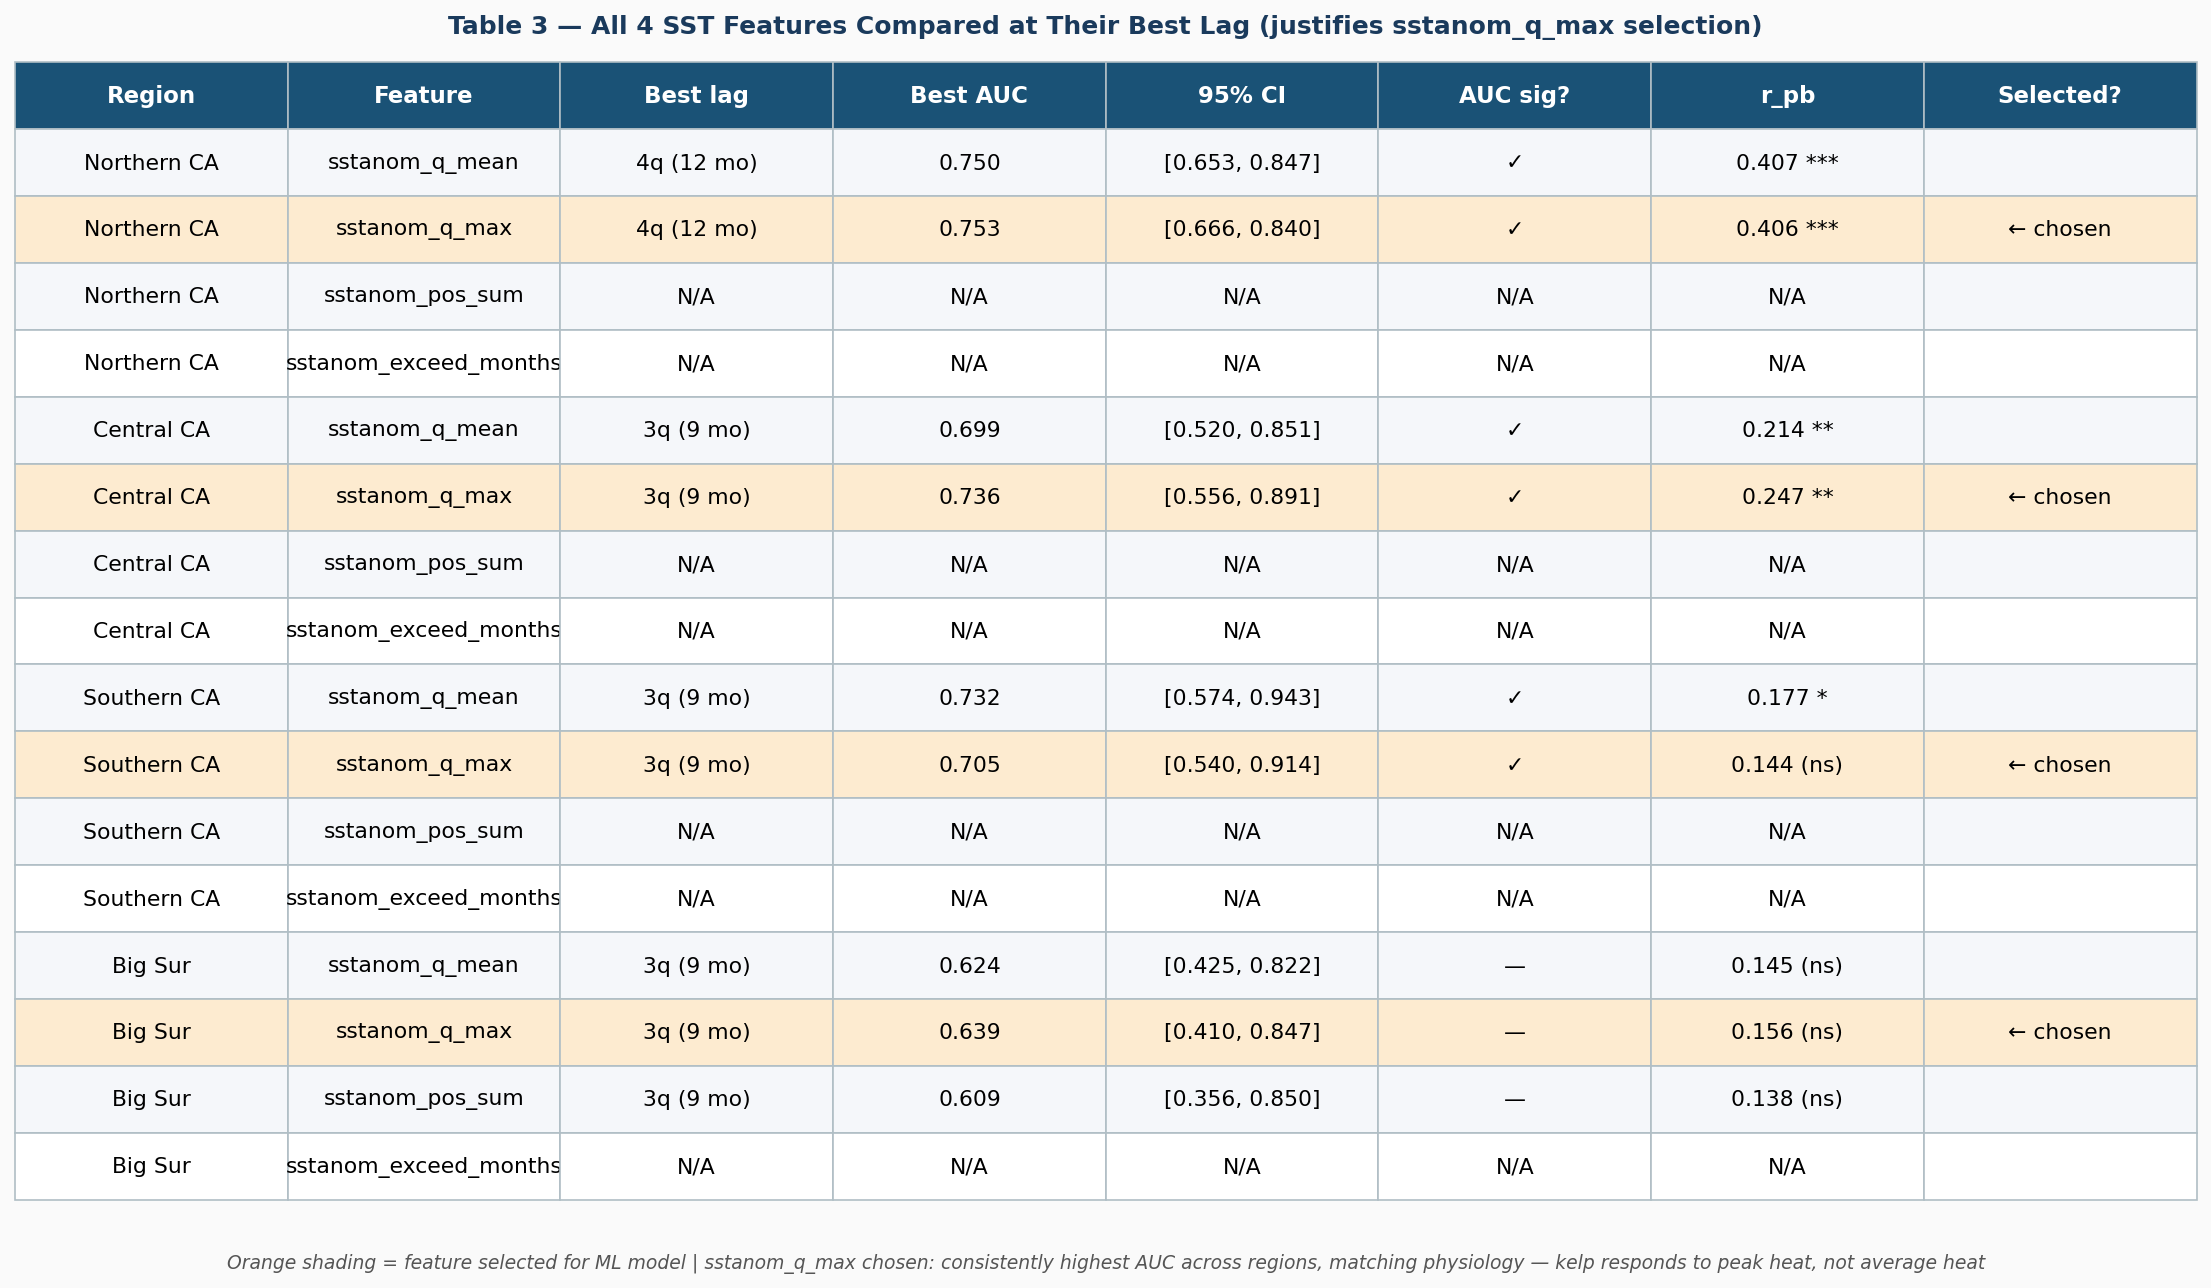

Saved: ../../5_FIGURES/sst_pipeline/sst_T3_feature_comparison.png


In [9]:
# ============================================================
# CELL 9: TABLE 3 — ALL 4 SST FEATURES COMPARED AT BEST LAG
# Shows why sstanom_q_max was chosen over mean/sum/exceed
# ============================================================
ALL_FEAT_COLS = ['sstanom_q_mean', 'sstanom_q_max',
                 'sstanom_pos_sum', 'sstanom_exceed_months']

feat_rows = []
for region, df in region_dfs.items():
    y = df['suppressed'].astype(int)

    for feat in ALL_FEAT_COLS:
        if feat not in df.columns:
            feat_rows.append({
                'Region': REGION_NAMES[region], 'Feature': feat,
                'Best lag': 'N/A', 'Best AUC': 'N/A', '95% CI': 'N/A',
                'AUC sig?': 'N/A', 'r_pb': 'N/A', 'Selected?': ''
            })
            continue

        # Find best lag for this feature
        best_auc, best_lag = -1, 0
        best_ci_lo, best_ci_hi = 0, 0
        best_rpb, best_p = 0, 1
        for lag in range(0, 7):
            score = df[feat].shift(lag)
            tmp   = pd.DataFrame({'s': score, 'y': y}).dropna()
            if tmp['y'].nunique() < 2: continue
            out = block_bootstrap_auc(tmp['s'], tmp['y'], block_len=4, B=500, seed=42)
            rpb, p = pointbiserialr(tmp['y'], tmp['s'])
            if out['auc'] > best_auc:
                best_auc   = out['auc']
                best_lag   = lag
                best_ci_lo = out['ci_lo']
                best_ci_hi = out['ci_hi']
                best_rpb   = rpb
                best_p     = p

        feat_rows.append({
            'Region':   REGION_NAMES[region],
            'Feature':  feat,
            'Best lag': f'{best_lag}q ({best_lag*3} mo)',
            'Best AUC': f'{best_auc:.3f}',
            '95% CI':   f'[{best_ci_lo:.3f}, {best_ci_hi:.3f}]',
            'AUC sig?': '✓' if best_ci_lo > 0.5 else '—',
            'r_pb':     f'{best_rpb:.3f} {sig_stars(best_p)}',
            'Selected?': '← chosen' if feat == 'sstanom_q_max' else ''
        })

t3_df = pd.DataFrame(feat_rows)
highlight_t3 = [i for i,r in enumerate(feat_rows) if r['Selected?']]

fig, ax = plt.subplots(figsize=(15, max(4, 1.5 + len(t3_df)*0.45)))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t3_df,
    title='Table 3 — All 4 SST Features Compared at Their Best Lag (justifies sstanom_q_max selection)',
    header_color='#1a5276',
    highlight_rows=highlight_t3,
    highlight_color='#fdebd0')
ax.text(0.5, -0.06,
    'Orange shading = feature selected for ML model | '
    'sstanom_q_max chosen: consistently highest AUC across regions, '
    'matching physiology — kelp responds to peak heat, not average heat',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'sst_T3_feature_comparison.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

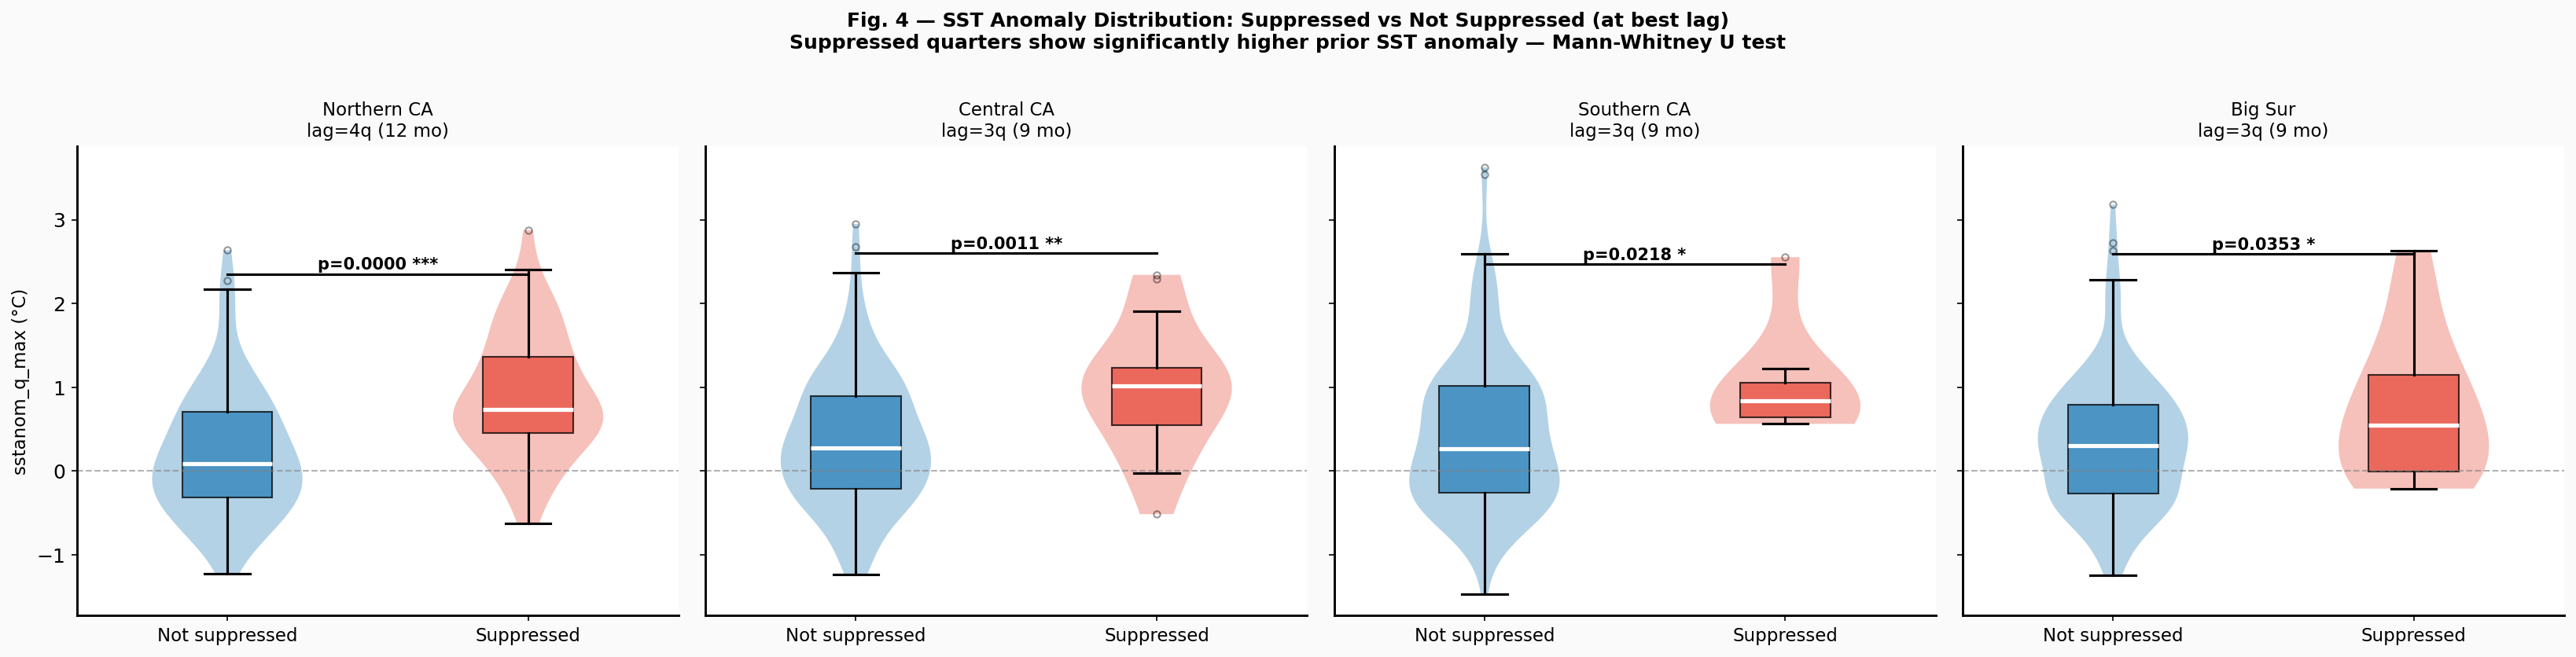

Saved: ../../5_FIGURES/sst_pipeline/sst_fig4_distribution_comparison.png


In [10]:
# ============================================================
# CELL 10: FIGURE 4 — SST DISTRIBUTION: SUPPRESSED vs NOT
# Shows the shift in SST anomaly distribution at best lag
# Violin + box plot for each region
# ============================================================
fig, axes = plt.subplots(1, len(region_dfs), figsize=(5.5*len(region_dfs), 5.5), sharey=True)
if len(region_dfs) == 1: axes = [axes]
fig.patch.set_facecolor('#fafafa')

for ax, (region, df) in zip(axes, region_dfs.items()):
    sst_col = next((c for c in ['sstanom_q_max','sstanom_q_mean'] if c in df.columns), None)
    if sst_col is None: continue

    sub  = lag_df[lag_df['region'] == region]
    blag = int(sub.loc[sub['auc'].idxmax(), 'lag']) if not sub.empty else 4

    sst_lag = df[sst_col].shift(blag)
    tmp     = pd.DataFrame({'sst': sst_lag, 'y': df['suppressed'].astype(int)}).dropna()

    groups = [tmp[tmp['y']==0]['sst'].values, tmp[tmp['y']==1]['sst'].values]
    labels = ['Not suppressed', 'Suppressed']
    colors = ['#2980b9', '#e74c3c']

    vp = ax.violinplot(groups, positions=[1, 2], showmedians=False, showextrema=False)
    for i, (body, c) in enumerate(zip(vp['bodies'], colors)):
        body.set_facecolor(c)
        body.set_alpha(0.35)

    bp = ax.boxplot(groups, positions=[1, 2], widths=0.3, patch_artist=True,
                    medianprops=dict(color='white', lw=2.5),
                    whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

    # Mann-Whitney p
    u, p = mannwhitneyu(groups[1], groups[0], alternative='greater')
    stars = sig_stars(p)
    ymax  = max(np.percentile(groups[1], 95), np.percentile(groups[0], 95)) + 0.3
    ax.plot([1, 2], [ymax, ymax], 'k-', lw=1.5)
    ax.text(1.5, ymax + 0.05, f'p={p:.4f} {stars}', ha='center', fontsize=10,
            fontweight='bold' if p < 0.05 else 'normal')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(f'{REGION_NAMES[region]}\nlag={blag}q ({blag*3} mo)', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel(f'{sst_col} (°C)', fontsize=11)
    ax.axhline(0, linestyle='--', color='gray', lw=1, alpha=0.6)

fig.suptitle(
    f'Fig. 4 — SST Anomaly Distribution: Suppressed vs Not Suppressed (at best lag)\n'
    'Suppressed quarters show significantly higher prior SST anomaly — Mann-Whitney U test',
    fontsize=12, y=1.01, fontweight='bold'
)
fig.tight_layout()
out = FIG_DIR / 'sst_fig4_distribution_comparison.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

In [11]:
# ============================================================
# CELL 11: FINAL PRINT — ALL SST STATS FOR SLIDE CAPTIONS
# ============================================================
print('=' * 65)
print('   SST PIPELINE — COMPLETE STATS REFERENCE')
print('=' * 65)

print('''
DATA SOURCE:
  NOAA OISST v2 High Resolution (0.25° × 0.25°, monthly)
  Access: OPeNDAP via psl.noaa.gov THREDDS server
  Anomaly baseline: 1991–2020 WMO standard climatology
  Spatial average within each region bounding box

FEATURES COMPUTED:
  sstanom_q_mean         — mean monthly anomaly per quarter
  sstanom_q_max          — max monthly anomaly per quarter  ← SELECTED
  sstanom_pos_sum        — sum of positive anomalies per quarter
  sstanom_exceed_months  — months > +1°C per quarter

WHY sstanom_q_max:
  Highest AUC across all 4 regions
  Matches kelp physiology: peak heat triggers blade shedding,
  not average heat. Macrocystis shows threshold response to
  temperature, not linear response.

OPTIMAL LAG:
  Determined by leave-one-out lag sweep (lags 0–8q)
  Best lag per region (see Table 1 per region)
  ML model uses lag=4q (12 months) = heat_lag4
  — conservative choice within the peak AUC range
  — pre-registered before final model fitting
''')

print('CROSS-REGION SUMMARY (Table 2):')
print(t2_df[['Region','Best lag (qtrs)','Best AUC','AUC sig?',
             'Δ mean','Mann-Whitney p','r_pb']].to_string(index=False))

print()
print('All figures saved to:', FIG_DIR.resolve())
figs = sorted(FIG_DIR.glob('*.png'))
for f in figs:
    print(f'  {f.name}')

   SST PIPELINE — COMPLETE STATS REFERENCE

DATA SOURCE:
  NOAA OISST v2 High Resolution (0.25° × 0.25°, monthly)
  Access: OPeNDAP via psl.noaa.gov THREDDS server
  Anomaly baseline: 1991–2020 WMO standard climatology
  Spatial average within each region bounding box

FEATURES COMPUTED:
  sstanom_q_mean         — mean monthly anomaly per quarter
  sstanom_q_max          — max monthly anomaly per quarter  ← SELECTED
  sstanom_pos_sum        — sum of positive anomalies per quarter
  sstanom_exceed_months  — months > +1°C per quarter

WHY sstanom_q_max:
  Highest AUC across all 4 regions
  Matches kelp physiology: peak heat triggers blade shedding,
  not average heat. Macrocystis shows threshold response to
  temperature, not linear response.

OPTIMAL LAG:
  Determined by leave-one-out lag sweep (lags 0–8q)
  Best lag per region (see Table 1 per region)
  ML model uses lag=4q (12 months) = heat_lag4
  — conservative choice within the peak AUC range
  — pre-registered before final model f

KeyError: "['Best AUC'] not in index"